## Module 0：全局参数与初始化
[E]：活性编辑器浓度
有效底物[S_accessible] ≤ [S_total]
binding：E + S ⇌ ES
catalysis：ES → E + P
产物释放与循环
rna降解与更新

动力学特征：
饱和效应
底物竞争：target RNA and off_target RNA
rate_limiting step：binding limit找不到 and catalysis limit酶效率低
反馈抑制

[E]：free PUF–APOBEC concentration
[S]：accessible APOE4 mRNA
[ES]：enzyme–substrate complex
[P]：edited RNA（APOE2-like）
（[S_inactive]，不可及底物（结构限制）*：[S_accessible] / [S_total]
[S_off]
[ES_off]
[E_inactive]
[S_total] = [S] + [P] + ...

1. 表达与降解（Expression / Degradation）
k_syn酶合成速率
k^deg_E酶降解速率
k_deg^SRNA降解速率
2.结合动力学
k_on:结合速率~10^5 – 10^7 M^{-1} s^{-1}*
k_off：解离速率
k_d=k_off/k_on
3.catalysis
k_cat:催化速率~~ 0.1 – 10 s^{-1}*实际有效
4.RNA动态
k_prod^S:RNA生成速率
k_decay^S:RNA自然降解

解离常数Kd​~
(5.结构可及性（可选）k_open	​结构打开速率k_close	​结构打开速率
6. off-target（扩展）)


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

## Module 1：AAV → 酶表达（输入函数 u(t)）
AAV进入细胞 → 表达 mRNA → 翻译 → 蛋白积累 → 降解
u(t):constant?/exp上升、饱和/……
先升后降：u(t)=umax​(1−e−kexp​t)e−kdecay​t

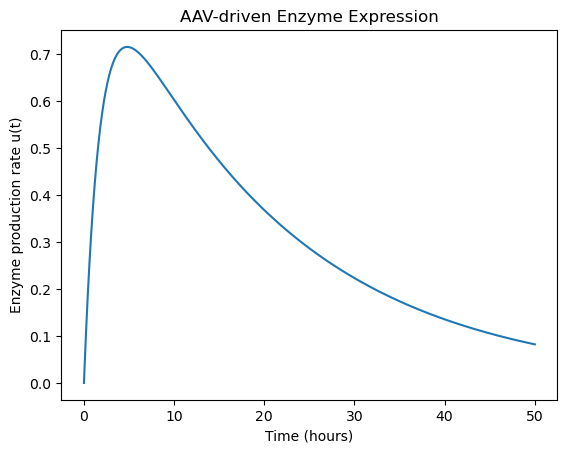

In [2]:
#u(t)=umax​(1−e−kexp​t)（2）
#u(t)=umax​(1−e−kexp​t)e−kdecay​t

# ==============================
# Module 1: AAV → Enzyme Expression u(t)
# ==============================

# ---------- 参数定义 ----------
# u_max: 最大表达速率（enzyme production rate）
# 单位可以理解为：浓度 / 时间（例如 nM / hour）
u_max = 1.0  

# k_exp: 表达上升速率（expression rate constant）
# 控制表达“启动有多快”
k_exp = 0.5  

# k_decay: 表达衰减速率（可选）
# 表示AAV表达逐渐下降（例如免疫反应/载体丢失）
k_decay = 0.05  


# ---------- 定义表达函数 ----------
def u(t, model="growth_decay"):
    """
    输入函数 u(t): 表示单位时间内生成的酶浓度
    
    参数:
    - t: 时间
    - model: 选择表达模型
        "constant"      → 恒定表达
        "growth"        → 指数增长后饱和
        "growth_decay"  → 先上升后下降（更真实）
    """
    
    if model == "constant":
        return u_max
    
    elif model == "growth":
        # u(t) = u_max * (1 - exp(-k_exp * t))
        return u_max * (1 - np.exp(-k_exp * t))
    
    elif model == "growth_decay":
        # u(t) = u_max * (1 - exp(-k_exp * t)) * exp(-k_decay * t)
        return u_max * (1 - np.exp(-k_exp * t)) * np.exp(-k_decay * t)
    
    else:
        raise ValueError("Unknown model type")


# ---------- 时间范围 ----------
t = np.linspace(0, 50, 500)  # 0~50小时


# ---------- 计算 ----------
u_values = [u(time) for time in t]


# ---------- 可视化 ----------
plt.figure()
plt.plot(t, u_values)
plt.xlabel("Time (hours)")
plt.ylabel("Enzyme production rate u(t)")
plt.title("AAV-driven Enzyme Expression")
plt.show()


In [ ]:
#可以做的扩展：moi感染率

## Module 2：酶动力学 ODE
AAV → u(t) → [E](t) → binding/catalysis → [P](t)
y = [E, S, ES, P]


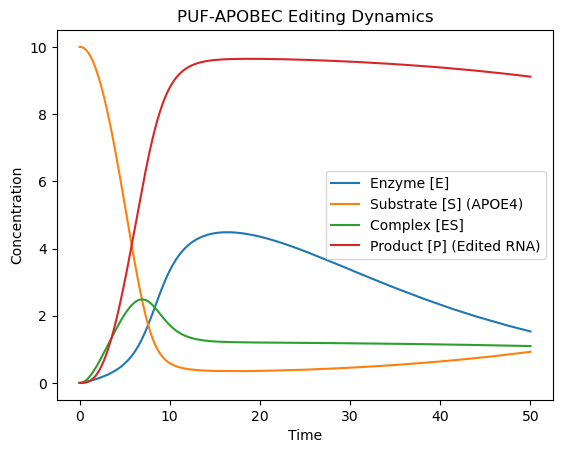

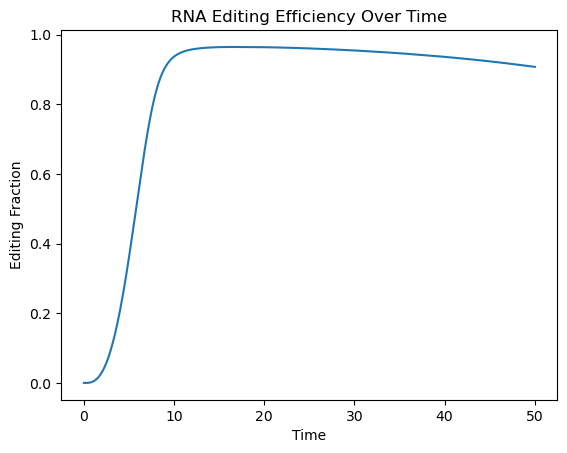

In [4]:

# ==============================
# 从 Module 1 引入 u(t)
# ==============================

u_max = 1.0
k_exp = 0.5
k_decay = 0.05

def u(t):
    """
    AAV驱动的酶表达速率函数 u(t)
    表示单位时间产生多少新的酶（PUF-APOBEC）
    """
    return u_max * (1 - np.exp(-k_exp * t)) * np.exp(-k_decay * t)


# ==============================
# 参数定义（动力学参数）
# ==============================

# --- 酶相关 ---
k_deg_E = 0.1      # 酶降解速率（E → ∅）

# --- RNA相关 ---
k_prod_S = 1.0     # APOE4 RNA生成速率
k_deg_S = 0.1      # RNA降解速率（对 S 和 P 都适用）

# --- 结合动力学 ---
k_on = 1.0         # 结合速率（E + S → ES）
k_off = 0.5        # 解离速率（ES → E + S）

# --- 催化 ---
k_cat = 0.8        # 编辑速率（ES → E + P）


# ==============================
# ODE系统定义
# ==============================

def ode_system(t, y):
    """
    y = [E, S, ES, P]
    
    每一项都是“浓度随时间的变化率”
    """
    E, S, ES, P = y

    # ---------- 输入 ----------
    u_t = u(t)  # 来自AAV模块

    # ---------- 方程 ----------
    
    # dE/dt：酶变化：
    dE_dt = (
        u_t                 # ➕ 新酶生成（AAV表达）
        - k_deg_E * E       # ➖ 酶降解
        - k_on * E * S      # ➖ 被底物占用形成ES
        + k_off * ES        # ➕ 解离回来
        + k_cat * ES        # ➕ 催化后释放（酶循环利用！）
    )

    # dS/dt：未编辑RNA
    dS_dt = (
        k_prod_S            # ➕ 新RNA生成
        - k_deg_S * S       # ➖ RNA降解
        - k_on * E * S      # ➖ 被酶结合
        + k_off * ES        # ➕ 解离回来
    )

    # dES/dt：复合物
    dES_dt = (
        k_on * E * S        # ➕ 形成复合物
        - k_off * ES        # ➖ 解离
        - k_cat * ES        # ➖ 被催化消耗
    )

    # dP/dt：编辑后RNA
    dP_dt = (
        k_cat * ES          # ➕ 编辑产生
        - k_deg_S * P       # ➖ RNA降解
    )

    return [dE_dt, dS_dt, dES_dt, dP_dt]


# ==============================
# 初始条件
# ==============================

E0 = 0.0     # 初始没有酶
S0 = 10.0    # 初始有一些APOE4 RNA
ES0 = 0.0
P0 = 0.0

y0 = [E0, S0, ES0, P0]


# ==============================
# 时间范围
# ==============================

t_span = (0, 50)
t_eval = np.linspace(0, 50, 500)


# ==============================
# 数值求解
# ==============================

solution = solve_ivp(
    ode_system,
    t_span,
    y0,
    t_eval=t_eval,
    method='RK45'
)


# ==============================
# 提取结果
# ==============================

t = solution.t
E, S, ES, P = solution.y


# ==============================
# 可视化
# ==============================

plt.figure()

plt.plot(t, E, label='Enzyme [E]')
plt.plot(t, S, label='Substrate [S] (APOE4)')
plt.plot(t, ES, label='Complex [ES]')
plt.plot(t, P, label='Product [P] (Edited RNA)')

plt.xlabel("Time")
plt.ylabel("Concentration")
plt.title("PUF-APOBEC Editing Dynamics")
plt.legend()
plt.show()


# ==============================
# 编辑效率（关键输出）
# ==============================

editing_ratio = P / (S + P + 1e-8)

plt.figure()
plt.plot(t, editing_ratio)
plt.xlabel("Time")
plt.ylabel("Editing Fraction")
plt.title("RNA Editing Efficiency Over Time")
plt.show()

## Module 3：RNA editing fraction（观测量）
ODE状态变量（E, S, ES, P） → 可观测量（editing metrics）

Module 3（强烈推荐）

做一个：参数扫描（parameter sweep）
例如：
k_cat vs editing efficiency
u_max vs final editing ratio

👉 直接出：
heatmap（非常加分）
或 Module 2.5（更高级）

加：
off-target
saturation分析
sensitivity analysis

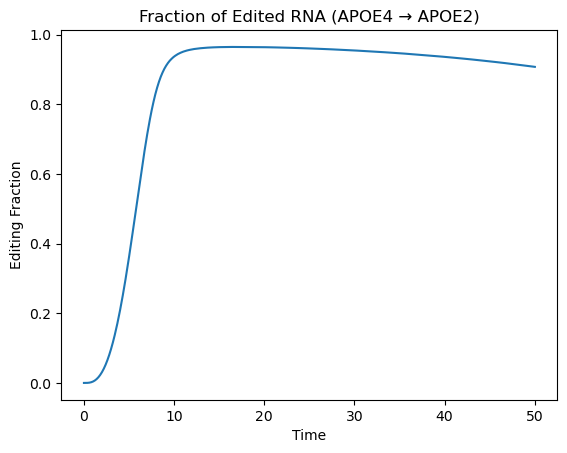

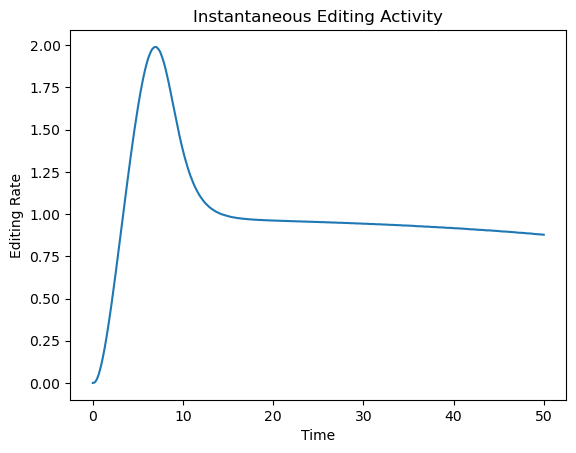

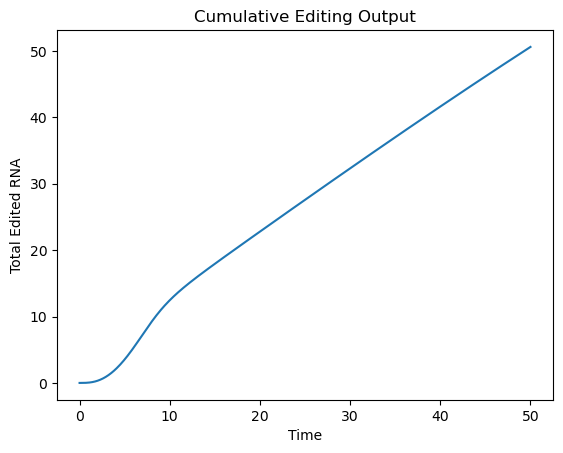

In [5]:
# ==============================
# Module 3: RNA Editing Metrics
# ==============================

# 防止除零
epsilon = 1e-8

# ---------- 1️⃣ Editing Fraction ----------
editing_fraction = P / (S + P + epsilon)

# ---------- 2️⃣ Instantaneous Editing Rate ----------
editing_rate = k_cat * ES

# ---------- 3️⃣ Cumulative Edited Amount ----------
# 数值积分（用累加近似积分）
dt = t[1] - t[0]
cumulative_edit = np.cumsum(editing_rate) * dt


# ==============================
# 可视化（非常关键！）
# ==============================

# --- Editing Fraction ---
plt.figure()
plt.plot(t, editing_fraction)
plt.xlabel("Time")
plt.ylabel("Editing Fraction")
plt.title("Fraction of Edited RNA (APOE4 → APOE2)")
plt.show()


# --- Editing Rate ---
plt.figure()
plt.plot(t, editing_rate)
plt.xlabel("Time")
plt.ylabel("Editing Rate")
plt.title("Instantaneous Editing Activity")
plt.show()


# --- Cumulative Editing ---
plt.figure()
plt.plot(t, cumulative_edit)
plt.xlabel("Time")
plt.ylabel("Total Edited RNA")
plt.title("Cumulative Editing Output")
plt.show()

## Module 4：参数扫描 / 可视化

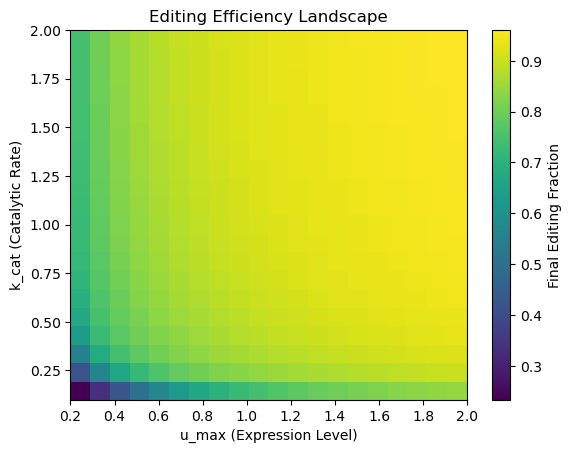

In [6]:

# ==============================
# 固定参数（不扫描的）
# ==============================

k_exp = 0.5
k_decay = 0.05

k_deg_E = 0.1
k_prod_S = 1.0
k_deg_S = 0.1

k_on = 1.0
k_off = 0.5


# ==============================
# 参数扫描范围
# ==============================

k_cat_values = np.linspace(0.1, 2.0, 20)     # 催化能力
u_max_values = np.linspace(0.2, 2.0, 20)     # 表达强度

# 结果矩阵
results = np.zeros((len(k_cat_values), len(u_max_values)))


# ==============================
# 主循环
# ==============================

for i, k_cat in enumerate(k_cat_values):
    for j, u_max in enumerate(u_max_values):

        # ---------- u(t) ----------
        def u(t):
            return u_max * (1 - np.exp(-k_exp * t)) * np.exp(-k_decay * t)

        # ---------- ODE ----------
        def ode_system(t, y):
            E, S, ES, P = y
            u_t = u(t)

            dE_dt = (
                u_t
                - k_deg_E * E
                - k_on * E * S
                + k_off * ES
                + k_cat * ES
            )

            dS_dt = (
                k_prod_S
                - k_deg_S * S
                - k_on * E * S
                + k_off * ES
            )

            dES_dt = (
                k_on * E * S
                - (k_off + k_cat) * ES
            )

            dP_dt = (
                k_cat * ES
                - k_deg_S * P
            )

            return [dE_dt, dS_dt, dES_dt, dP_dt]

        # ---------- 初始条件 ----------
        y0 = [0.0, 10.0, 0.0, 0.0]

        # ---------- 求解 ----------
        sol = solve_ivp(
            ode_system,
            (0, 50),
            y0,
            t_eval=[50]   # 只取最终值（提高速度）
        )

        E, S, ES, P = sol.y[:, -1]

        # ---------- 计算最终编辑效率 ----------
        editing_fraction = P / (S + P + 1e-8)

        results[i, j] = editing_fraction


# ==============================
# 可视化（Heatmap）
# ==============================

plt.figure()

plt.imshow(
    results,
    origin='lower',
    aspect='auto',
    extent=[u_max_values[0], u_max_values[-1],
            k_cat_values[0], k_cat_values[-1]]
)

plt.colorbar(label='Final Editing Fraction')

plt.xlabel("u_max (Expression Level)")
plt.ylabel("k_cat (Catalytic Rate)")
plt.title("Editing Efficiency Landscape")

plt.show()

🟢 区域 1：低 u_max + 低 k_cat
几乎没有编辑
👉 原因：酶少 + 活性低

🟡 区域 2：高 u_max + 低 k_cat
有一定编辑，但有限
👉 原因：人多但效率低

🟡 区域 3：低 u_max + 高 k_cat
仍然有限👉 
原因：工人少，再强也不够

🔴 区域 4：高 u_max + 高 k_cat
高编辑效率（接近1）